<a href="https://colab.research.google.com/github/adwoaadusei/lab-3/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


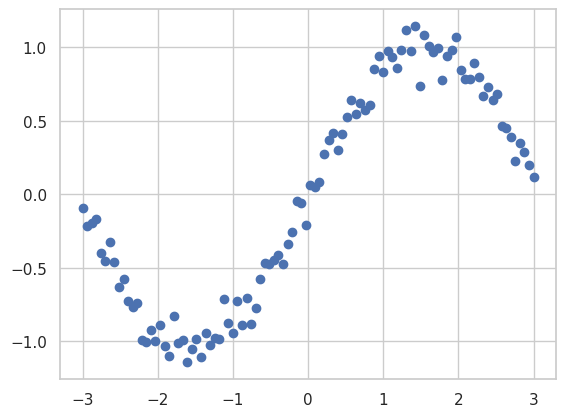

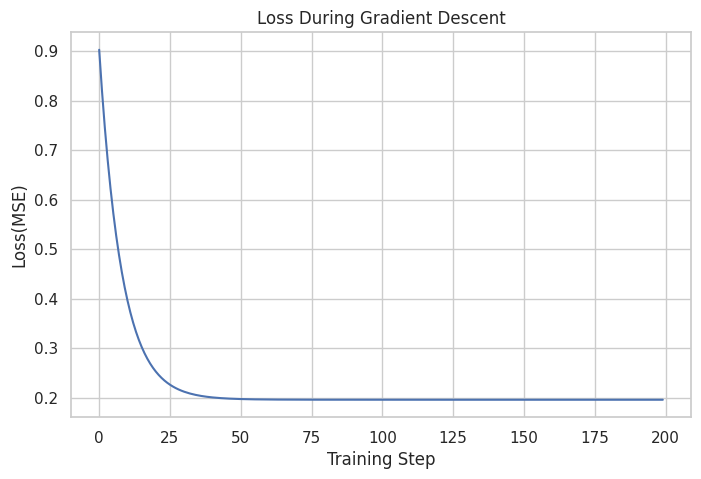

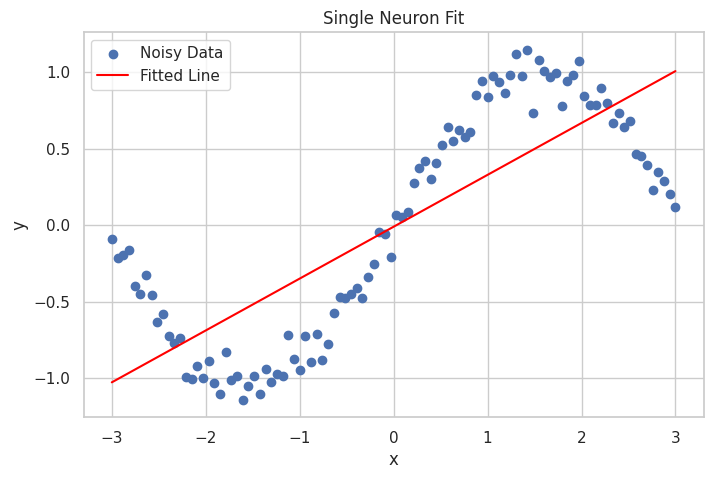

In [64]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, 100)
y = np.sin(x) + noise
plt.plot(x, y, 'o')
#plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.normal(0, 0.1)
b = np.random.normal(0, 0.1)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
#   Record the loss at every step.

losses = []
for step in range(200):
  y_hat = w * x + b
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)
  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))
  lr = 0.01
  w -= lr * dw
  b -= lr * db

  # TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss(MSE)")
plt.title("Loss During Gradient Descent")
plt.grid(True)

plt.figure(figsize=(8,5))
plt.scatter(x,y,label="Noisy Data")
plt.plot(x,y_hat,color="red",label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single Neuron Fit")
plt.legend()
plt.grid(True)
plt.show()


1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?
 Yes it meatches the code.
 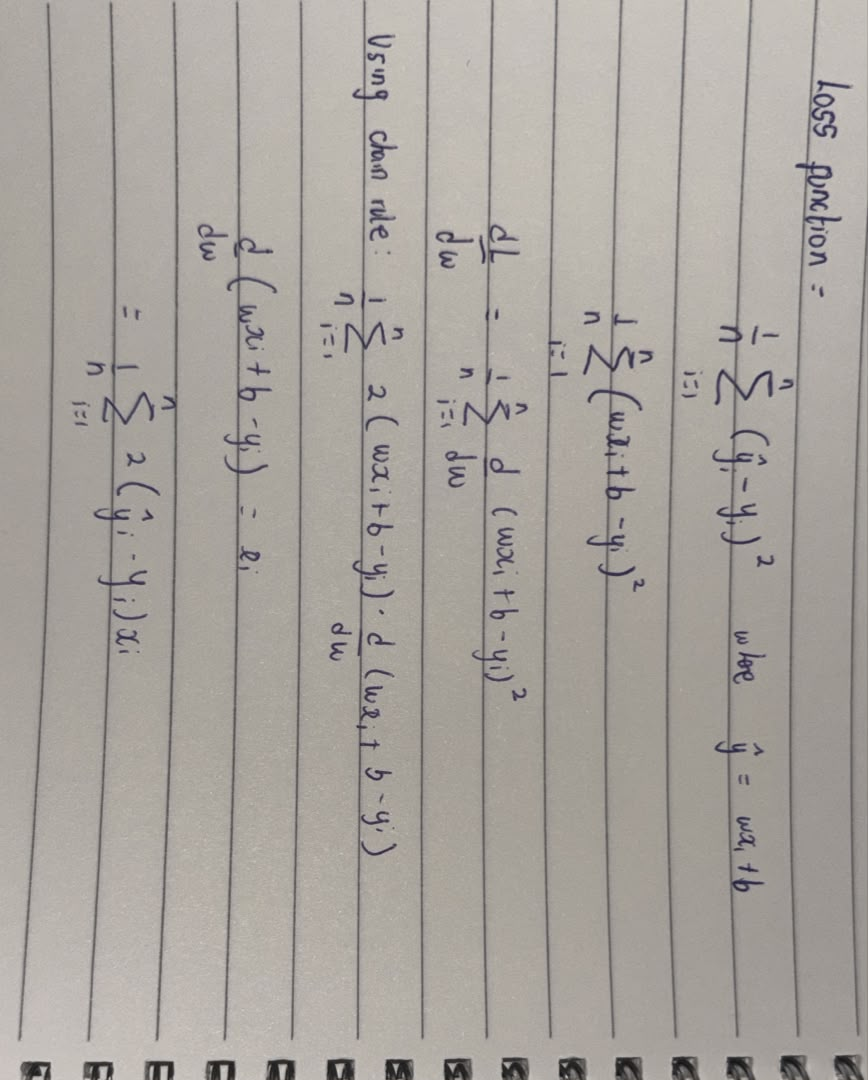

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

The neuron always uses y = wx + b which is a straight line. A sine curve function is a curve and a straight line can never become a curve. Eventually, the model will stop improving because it has reached the best straightline approximation of the data. Therefore it is underfitting.

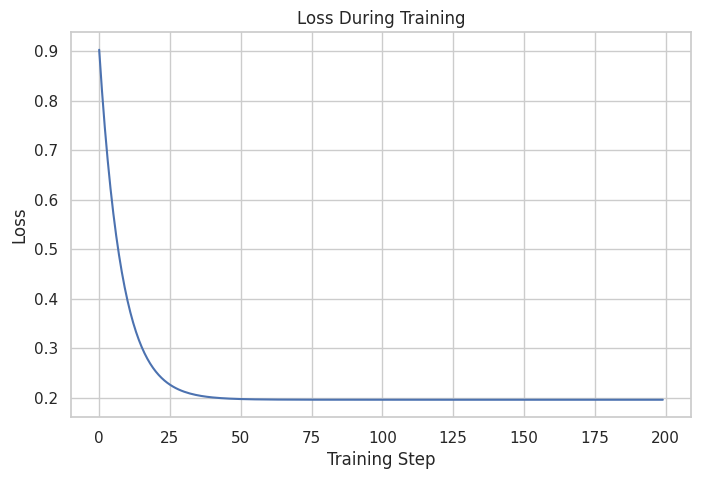

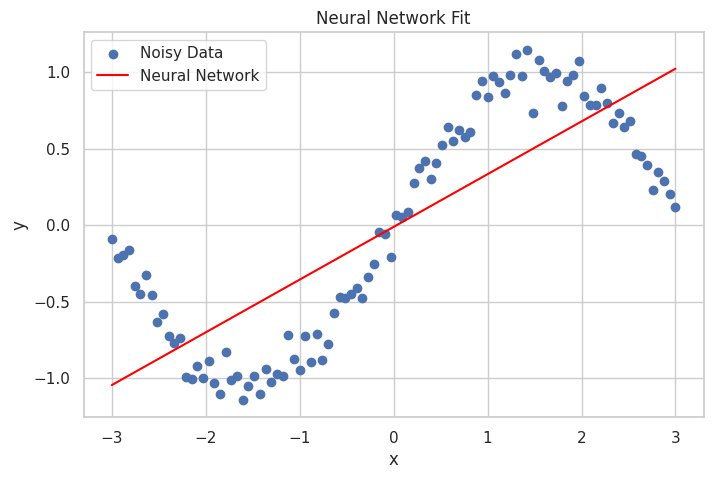

In [65]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

w1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
w2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
x = x.reshape(-1,1)
y = y.reshape(-1,1)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss
lr = 0.001
loss_list = []
for step in range(3000):
  z1 = x @ w1 + b1
  h = z1
  y_hat = h @ w2 + b2
  loss = np.mean((y_hat - y) ** 2)
  loss_list.append(loss)

  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ w2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  w1 -= lr * dW1
  b1 -= lr * db1
  w2 -= lr * dW2
  b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss During Training")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Noisy Data")
plt.plot(x, y_hat, color="red", label="Neural Network")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Fit")
plt.legend()
plt.show()








1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.

Since a linearlayer is y = wx+b. So stacking linear layers without a non-linear activation is mathemathically equivalent to s ingle linear layer.

 2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)

 The 8 hidden neurons each learned a different nonlinear feature of the input after the tanh activation. These causes their outputs to form a richer representation of the data. This allows the output neuron to combine these feature and approximate the curved shape of the sine function. Without these hidden neurons, the network would only be able to produce a striaght line.

 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?

 Backpropagation is the process of applying the chain rule to compute the gradients of the loss wrt to every parameter in the neural network so the wieghts and biases can be updated using gradient descent.

/tmp/ipykernel_3359/1994142142.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_3359/1994142142.py:28: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ w2.T
/tmp/ipykernel_3359/1994142142.py:29: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


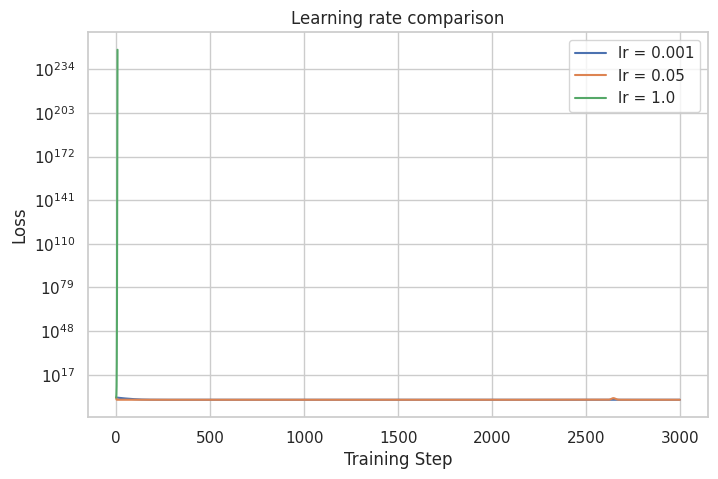

In [66]:

# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend

def train_toy(lr,steps=3000):
  np.random.seed(42)

  w1 = np.random.randn(1,8) * 0.5
  b1 = np.random.randn(8) * 0.5
  w2 = np.random.randn(8,1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses =[]
  for step in range(steps):
    z1 = x @ w1 + b1
    h = z1
    y_hat = h @ w2 + b2
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2

  return losses

loss_1 = train_toy(0.001)
loss_2 = train_toy(0.05)
loss_3 = train_toy(1.0)

plt.figure(figsize=(8,5))

plt.plot(loss_1, label="lr = 0.001")
plt.plot(loss_2, label="lr = 0.05")
plt.plot(loss_3, label="lr = 1.0")

plt.yscale("log")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Learning rate comparison")
plt.grid(True)
plt.legend()

plt.show()





Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?



*   lr = 0.001. The loss decreases steadily but slowly because the parameter updates are small, resulting in stable but slow convergence
*   lr = 0.05. The loss increases ,much faster but remains stable making it the most effective
*   lr = 1.0 . The loss increases too quicly, overflows and eventually becomes name meaning this rate is too large for

Instead of moving closer to the minimum, the updates jump past it causing the loss to increase uncontrollably





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

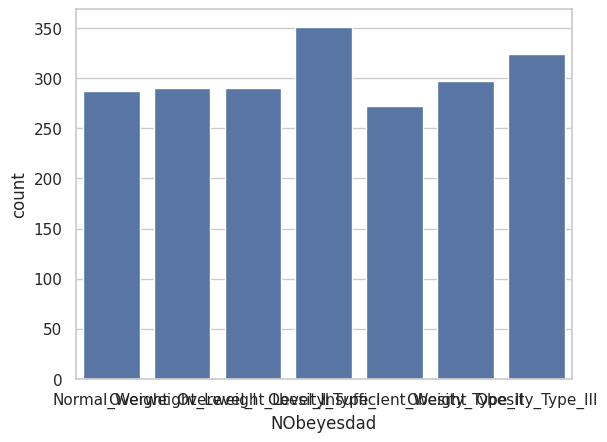

['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


/tmp/ipykernel_3359/2665441179.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  obesity[binary_columns] = obesity[binary_columns].replace({"no": 0, "yes": 1})


In [67]:

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

obesity = pd.read_csv(OBESITY_URL)
obesity.shape
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()
obesity["NObeyesdad"].value_counts()
sns.countplot(data=obesity, x="NObeyesdad")
plt.show()

print(obesity.columns.tolist())

binary_columns = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
obesity[binary_columns] = obesity[binary_columns].replace({"no": 0, "yes": 1})
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"])
order = ["no", "Sometimes", "Frequently", "Always"]
obesity["CAEC"] = obesity["CAEC"].astype("category").cat.set_categories(order, ordered=True)
obesity["CALC"] = obesity["CALC"].astype("category").cat.set_categories(order, ordered=True)
obesity["CAEC"] = obesity["CAEC"].cat.codes
obesity["CALC"] = obesity["CALC"].cat.codes

obesity["BMI"] = obesity["Weight"] / obesity["Height"]**2

X = obesity.drop(columns=["NObeyesdad"])
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(obesity["NObeyesdad"])
#y = obesity["NObeyesdad"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler.fit(X_train[numeric_columns])
X_train[numeric_columns] = scaler.transform(X_train[numeric_columns])
X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])


import torch
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
X_val = torch.tensor(X_val.to_numpy(), dtype=torch.float32)
X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?
Cross Entropy Loss uses integer class labels(0-6) because it expect the index of the correct class, not a one-hot vector

2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks use gradients, in Section 1, the weight gradient was

dL/dw = 1/n sigma 2(y_hat -y)x

Since the gradient is multiplied by the input feature x, features with much larger values produce much larger gradients, leading to unstable or slow training.Scaling keeps the gradients stableand improves training

3. What does shuffle=True on the training DataLoader do, and why does it help?

It randomizes the training data epoch, helping the model learn beeter and reduce overfitting.

In [68]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
    self.relu1 = nn.ReLU()
    self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
    self.relu2 = nn.ReLU()
    self.output = nn.Linear(hidden_sizes[1], n_classes)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu1(x)
    x = self.fc2(x)
    x = self.relu2(x)
    x = self.output(x)
    return x
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=(64, 32), n_classes=7)
model.to(DEVICE)
print(model)
sum(p.numel() for p in model.parameters() if p.requires_grad)

FeedForwardNet(
  (fc1): Linear(in_features=22, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=32, out_features=7, bias=True)
)


3783

1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.
FeedForwardNet(
  (fc1): Linear(in_features=22, out_features=64, bias=True) = 22 * 64 + 64 = 1472
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True) = 64 * 32 + 32 = 2080
  (relu2): ReLU()
  (output): Linear(in_features=32,  out_features=7, bias=True) = 32 * 7 + 7 = 231
) Total = 1472 + 2080 + 231 = 3783. This matches pytorch's parameter count of 3783

2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.

ReLU is computationally simpler. It helps reduce the vanishing gradient problem making training faster and more effective.

3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

Without the ReLUs, the networkwould be equivalent to a single linear layer so it could only learn a linear relationship


Epoch  1/50: Train Loss: 1.8759, Train Acc: 0.2899, Val Loss: 1.7564, Val Acc: 0.4408
Epoch  2/50: Train Loss: 1.5487, Train Acc: 0.4913, Val Loss: 1.3068, Val Acc: 0.5664
Epoch  3/50: Train Loss: 1.1137, Train Acc: 0.6485, Val Loss: 0.9379, Val Acc: 0.7251
Epoch  4/50: Train Loss: 0.8275, Train Acc: 0.7472, Val Loss: 0.7204, Val Acc: 0.7820
Epoch  5/50: Train Loss: 0.6488, Train Acc: 0.8081, Val Loss: 0.5901, Val Acc: 0.8270
Epoch  6/50: Train Loss: 0.5263, Train Acc: 0.8499, Val Loss: 0.4827, Val Acc: 0.8697
Epoch  7/50: Train Loss: 0.4387, Train Acc: 0.8839, Val Loss: 0.4075, Val Acc: 0.8886
Epoch  8/50: Train Loss: 0.3713, Train Acc: 0.9013, Val Loss: 0.3457, Val Acc: 0.8981
Epoch  9/50: Train Loss: 0.3177, Train Acc: 0.9218, Val Loss: 0.3101, Val Acc: 0.9123
Epoch 10/50: Train Loss: 0.2721, Train Acc: 0.9408, Val Loss: 0.2749, Val Acc: 0.9336
Epoch 11/50: Train Loss: 0.2363, Train Acc: 0.9471, Val Loss: 0.2583, Val Acc: 0.9218
Epoch 12/50: Train Loss: 0.2089, Train Acc: 0.9566, Va

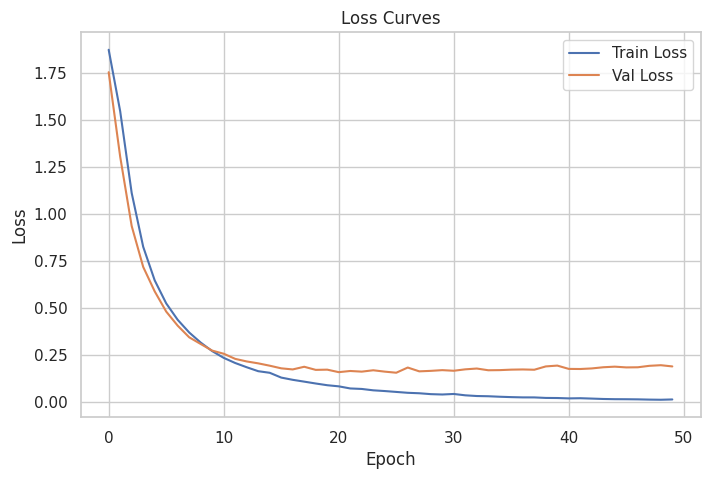

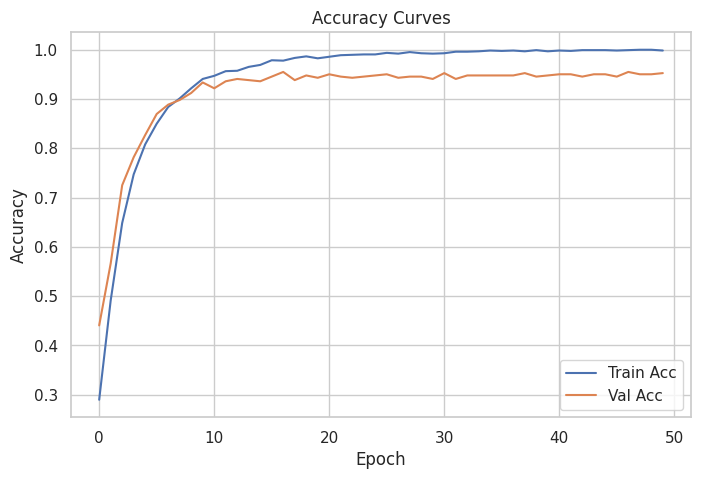

In [69]:

# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


import torch
import torch.nn as nn
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

best_val_acc = 0

for epoch in range(50):
  model.train()
  running_loss = 0
  correct = 0
  train = 0

  for xb, yb in train_loader:
    xb = xb.to(DEVICE)
    yb = yb.to(DEVICE)
    optimizer.zero_grad()
    logits = model(xb)
    loss = criterion(logits, yb)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() * xb.size(0)
    predicted = torch.argmax(logits.data, dim=1)
    correct += (predicted == yb).sum().item()
    train += yb.size(0)

  train_loss = running_loss / train
  train_acc = correct / train


  model.eval()

  running_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for xb,yb in val_loader:
      xb = xb.to(DEVICE)
      yb = yb.to(DEVICE)
      logits = model(xb)
      loss = criterion(logits, yb)

      running_loss += loss.item() * xb.size(0)
      predicted = torch.argmax(logits.data, dim=1)
      correct += (predicted == yb).sum().item()
      total += yb.size(0)

  val_loss = running_loss/total
  val_acc = correct/total

  train_loss_history.append(train_loss)
  val_loss_history.append(val_loss)
  train_acc_history.append(train_acc)
  val_acc_history.append(val_acc)

  if val_acc> best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), "ffn_best.pt")

  print(f"Epoch {epoch+1:2d}/{50}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.figure(figsize=(8,5))
plt.plot(train_acc_history, label="Train Acc")
plt.plot(val_acc_history, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()

1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?
Forward pass : logits = model(xb)
Compute gradients(Backpropagation) : loss.backward()
Update rule(Gradient descent) : optimizer.step()

2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.
The model is overfitting. The training accuracy reaches 100% while the validation accuracy stays around 95%-96%. ALso the training loss becomes very low while the validation loss increases, showing that it does better with the training set than with the validation set.

3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?
It clears the old gradients before computing new ones. Without it the gradients will accumulate across batches causing incorrect weight updates.

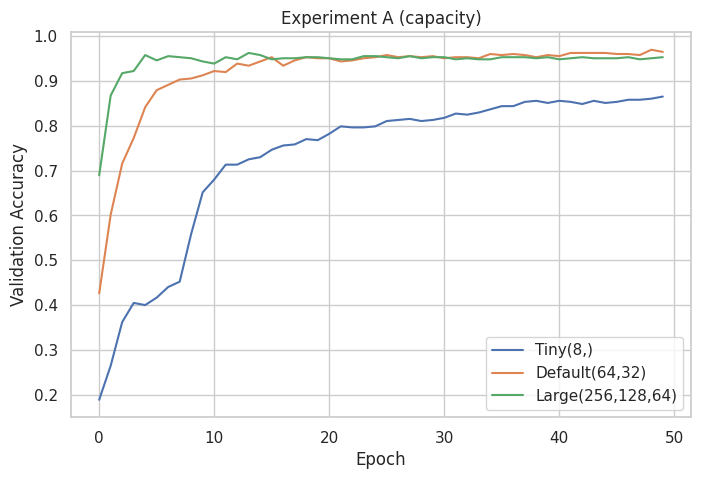

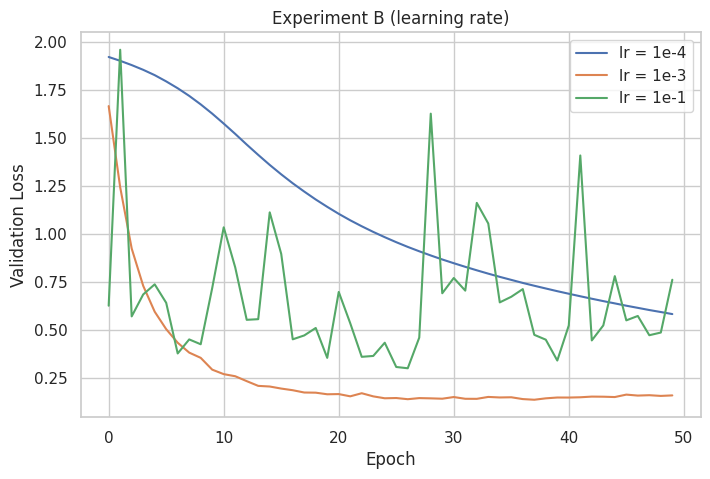

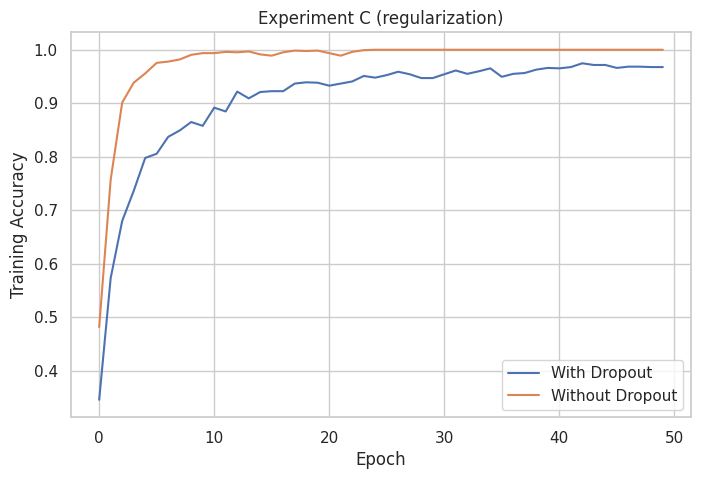

In [70]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes=(64,32), n_classes=7, dropout=0.0):
    super().__init__()

    layers = []
    in_features = input_dim

    for hidden in hidden_sizes:
      layers.append(nn.Linear(in_features, hidden))
      layers.append(nn.ReLU())

      if dropout > 0:
        layers.append(nn.Dropout(dropout))

      in_features = hidden

    layers.append(nn.Linear(in_features, n_classes))
    self.layers = nn.Sequential(*layers)

  def forward(self, x):
    return self.layers(x)



def run_experiment(hidden_sizes=(64,32),lr=1e-3,batch_size=32,epochs=50,dropout=0.0):
  model = FeedForwardNet(input_dim=X_train.shape[1],hidden_sizes=hidden_sizes, dropout=dropout)
  model.to(DEVICE)
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  train_loss_history = []
  val_loss_history = []
  train_acc_history = []
  val_acc_history = []

  best_val_acc = 0

  for epoch in range(50):
    model.train()
    running_loss = 0
    correct = 0
    train = 0

    for xb, yb in train_loader:
      xb = xb.to(DEVICE)
      yb = yb.to(DEVICE)
      optimizer.zero_grad()
      logits = model(xb)
      loss = criterion(logits, yb)
      loss.backward()
      optimizer.step()
      running_loss += loss.item() * xb.size(0)
      predicted = torch.argmax(logits.data, dim=1)
      correct += (predicted == yb).sum().item()
      train += yb.size(0)

    train_loss = running_loss / train
    train_acc = correct / train


    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
      for xb,yb in val_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        predicted = torch.argmax(logits.data, dim=1)
        correct += (predicted == yb).sum().item()
        total += yb.size(0)

    val_loss = running_loss/total
    val_acc = correct/total

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    if val_acc> best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "ffn_best.pt")

  return {
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
    "train_acc": train_acc_history,
    "val_acc": val_acc_history,
  }
#A
small= run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128,64))

#B
lr1 = run_experiment(lr=1e-4)
lr2 = run_experiment(lr=1e-3)
lr3 = run_experiment(lr=1e-1)

#C
with_dropout = run_experiment(hidden_sizes=(256,128,64),dropout=0.3)
without_dropout = run_experiment(hidden_sizes=(256,128,64),dropout=0.0)

plt.figure(figsize=(8,5))
plt.plot(small["val_acc"], label = "Tiny(8,)")
plt.plot(default["val_acc"], label = "Default(64,32)")
plt.plot(large["val_acc"], label = "Large(256,128,64)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A (capacity)")
plt.legend()

plt.figure(figsize=(8,5))
plt.plot(lr1["val_loss"], label = "lr = 1e-4")
plt.plot(lr2["val_loss"], label = "lr = 1e-3")
plt.plot(lr3["val_loss"], label = "lr = 1e-1")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B (learning rate)")
plt.legend()

plt.figure(figsize=(8,5))
plt.plot(with_dropout["train_acc"], label = "With Dropout")
plt.plot(without_dropout["train_acc"], label = "Without Dropout")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Experiment C (regularization)")
plt.legend()
plt.show()

1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?
The largest network had the best validation accuracy but only performed a little better than the default. The tiny network performed the worst

2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?
Yes. 1e-4 learned slowly, 1e-3 was the best and 1e-1 was unstable

3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.
It reduced overfitting by lowering training accuracy while keeping validation accuracy high. It works by randomly disabling some neurons during training which then forces the network to learn morerobust features instead or relying on specific neurons

Test Accuracy: 0.9645
Test Macro-F1: 0.9641
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       0.98      0.91      0.95        58
           2       0.93      1.00      0.97        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.90      0.97      0.93        58
           6       0.98      0.90      0.94        58

    accuracy                           0.96       423
   macro avg       0.97      0.96      0.96       423
weighted avg       0.97      0.96      0.96       423



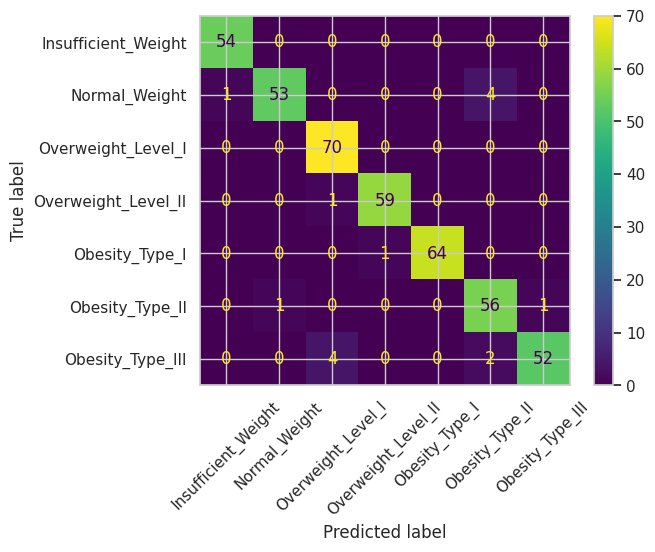

,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters/Trees
0,Lab 2 Classifier,Ellipsis,Ellipsis,...,...
1,Neural Network,0.964539,0.964089,...,47495


In [73]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd

model = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=(256,128,64)).to(DEVICE)
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval

y_true = []
y_pred = []

with torch.no_grad():
  for xb,yb in test_loader:
    xb = xb.to(DEVICE)
    logits = model(xb)
    predicted = torch.argmax(logits.data, dim=1)
    y_true.extend(yb.tolist())
    y_pred.extend(predicted.tolist())

test_acc = accuracy_score(y_true,y_pred)
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print(classification_report(y_true,y_pred))

class_names = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation=45
)
plt.show()

comparison = pd.DataFrame({
    "Model": ["Lab 2 Classifier", "Neural Network"],
    "Test Accuracy": [..., test_acc],
    "Test Macro-F1": [..., test_f1],
    "Training Time": ["...", "..."],
    "Parameters/Trees": ["...", sum(p.numel() for p in model.parameters())]
})

comparison

1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?
It confuses Normal Weight with Obesity Type II and Obesity Type III with overweight Level I / Obesity Type 2. Yes they are similae

 2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?
 The neural network performed slightly better with 96.45 accuracy and0.964 Macro-F1.On this dataset, the improvement is small, so the extra effort may not be worth it. Deep learning is more useful for much larger and more complex datasets.